# Parallel Trends Check (Regression-Based Event-Study)

## Overview

This notebook checks the parallel pre-trends assumption for the hospital merger DiD project using only regression-based staggered DiD event-study diagnostics.

It does not use raw average event-time line plots. All conclusions are based on regression coefficients and joint pre-trend F-tests.

## Design Context

The event-study approach estimates how treated and control hospitals moved before the merger event, after absorbing hospital and year fixed effects.

For each sample and subgroup, we estimate:

- Event-time coefficients for periods -4, -3, -2, 0, +1, +2 relative to each hospital's merger year
- Event time -1 is omitted as the reference period
- Never-treated hospitals serve as controls through the fixed-effects structure
- We do not assign pseudo-event time to never-treated hospitals

## Objectives

- Load and clean the hospital panel from `01_data/hospital_analysis.csv`
- Construct log cost per discharge and event-time indicators
- Estimate the regression-based event-study for the full sample
- Repeat for subgroups: small hospitals, ownership types, and ownership + size
- Run joint pre-trend F-tests on pre-treatment coefficients (-4, -3, -2)
- Summarize and interpret results across all subgroups

## Dataset Description

The notebook uses the full hospital panel in `01_data/hospital_analysis.csv`.

Core variables include `PRVDR_NUM`, `fiscal_year`, `treated`, `merger_year`, `cost_per_discharge`, `total_discharges`, and `PRVDR_CTRL_TYPE_CD`.

The primary outcome is `log_cost = log(cost_per_discharge)`.

## Key Considerations

- This notebook is diagnostic only — it does not estimate the DiD treatment effect
- A joint pre-trend test that does not reject is more consistent with parallel pre-trends, but is not proof of them
- A joint pre-trend test that rejects raises concerns, but does not prove the assumption is violated
- Results should be interpreted in the context of sample size, subgroup composition, and model fit

## Outcome

By the end of this notebook, you get event-study coefficient plots and joint pre-trend p-values for the full sample and all subgroups, plus a summary table and a careful interpretation.

## 2. Import packages and load data

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from IPython.display import display


out_dir = Path("../04_outputs/figures")
out_dir.mkdir(parents=True, exist_ok=True)

data_path = Path("../01_data/hospital_analysis.csv")
df = pd.read_csv(data_path)
print("Raw data shape:", df.shape)

Raw data shape: (55805, 30)


## 3. Clean data and create log_cost

In [36]:
needed_cols = [
    "PRVDR_NUM",
    "fiscal_year",
    "treated",
    "merger_year",
    "cost_per_discharge",
    "total_discharges",
    "PRVDR_CTRL_TYPE_CD",
]

df = df[needed_cols]

df = df.dropna(
    subset=[
        "PRVDR_NUM",
        "fiscal_year",
        "treated",
        "cost_per_discharge",
        "total_discharges",
        "PRVDR_CTRL_TYPE_CD",
    ]
)

df = df[df["treated"].isin([0, 1])]
df = df[df["cost_per_discharge"] > 0]

df["treated"] = df["treated"].astype(int)
df["fiscal_year"] = df["fiscal_year"].astype(int)
df["PRVDR_CTRL_TYPE_CD"] = df["PRVDR_CTRL_TYPE_CD"].astype(int)

df["log_cost"] = np.log(df["cost_per_discharge"])

print("Cleaned data shape:", df.shape)
print("Unique hospitals:", df["PRVDR_NUM"].nunique())
print("Treated hospitals:", df.loc[df["treated"] == 1, "PRVDR_NUM"].nunique())
print("Never-treated hospitals:", df.loc[df["treated"] == 0, "PRVDR_NUM"].nunique())

Cleaned data shape: (53354, 8)
Unique hospitals: 6461
Treated hospitals: 1242
Never-treated hospitals: 5219


## 4. Define event-time window and event-study indicators

In [37]:
# Define pre-treatment event-time window for the parallel-trends check.
# event_time = -1 is the reference period, so we do not create a dummy for it.

event_window = [-4, -3, -2, -1]
event_terms = [-4, -3, -2]

event_map = {
    -4: "ev_m4",
    -3: "ev_m3",
    -2: "ev_m2",
}

# Event time is only meaningful for treated hospitals.
df["event_time"] = df["fiscal_year"] - df["merger_year"]

# Create pre-treatment event-time indicators for treated hospitals only.
for k in event_terms:
    col = event_map[k]
    df[col] = ((df["treated"] == 1) & (df["event_time"] == k)).astype(int)

event_cols = [event_map[k] for k in event_terms]

print("Pre-treatment event-time window:", event_window)
print("Reference period omitted: event_time = -1")
print("Pre-treatment event indicators:", event_cols)

display(df[event_cols].sum().to_frame("count"))

Pre-treatment event-time window: [-4, -3, -2, -1]
Reference period omitted: event_time = -1
Pre-treatment event indicators: ['ev_m4', 'ev_m3', 'ev_m2']


,count
ev_m4,605
ev_m3,787
ev_m2,1006


## 5. Regression-based event-study

In [ ]:
# Full-sample regression-based pre-trend check

pre_event_cols = ["ev_m4", "ev_m3", "ev_m2"]

X_full = pd.concat(
    [
        df[pre_event_cols],
        pd.get_dummies(df["PRVDR_NUM"], prefix="h", drop_first=True),
        pd.get_dummies(df["fiscal_year"], prefix="y", drop_first=True),
    ],
    axis=1,
).astype(float)

X_full = add_constant(X_full)
y_full = df["log_cost"].astype(float)

full_res = OLS(y_full, X_full).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["PRVDR_NUM"]},
)

print("Full sample rows:", len(df))
print("Reference period omitted: event_time = -1")
print("Pre-treatment indicators used:", pre_event_cols)

display(full_res.params[pre_event_cols].to_frame("estimate"))

## 6. Coefficient plot with 95% confidence intervals

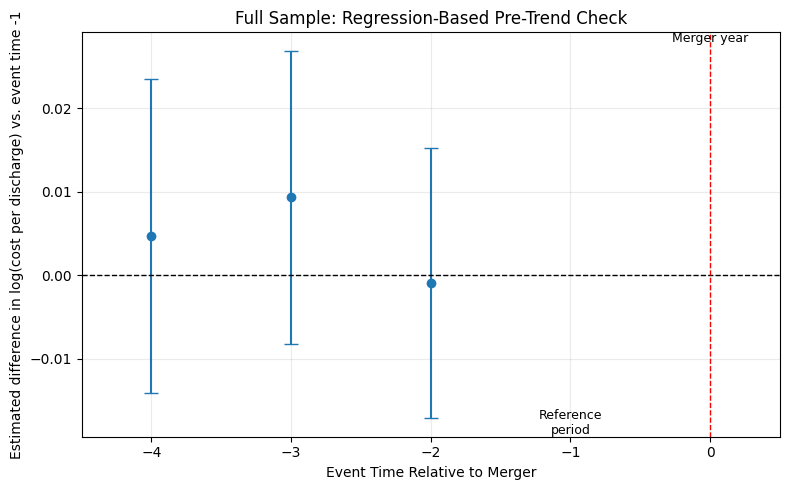

,event_time,estimate,standard_error,p_value,ci_95_low,ci_95_high
0,-4,0.0047,0.0096,0.6263,-0.0142,0.0235
1,-3,0.0093,0.0090,0.2994,-0.0083,0.0269
2,-2,-0.0010,0.0083,0.9045,-0.0172,0.0152


In [ ]:
z = 1.96

pre_event_times = [-4, -3, -2]
pre_event_cols = ["ev_m4", "ev_m3", "ev_m2"]

full_coef = pd.DataFrame(
    {
        "event_time": pre_event_times,
        "estimate": [full_res.params[col] for col in pre_event_cols],
        "standard_error": [full_res.bse[col] for col in pre_event_cols],
        "p_value": [full_res.pvalues[col] for col in pre_event_cols],
    }
)

full_coef["ci_95_low"] = full_coef["estimate"] - z * full_coef["standard_error"]
full_coef["ci_95_high"] = full_coef["estimate"] + z * full_coef["standard_error"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    full_coef["event_time"],
    full_coef["estimate"],
    yerr=z * full_coef["standard_error"],
    fmt="o",
    markersize=6,
    capsize=5,
    linewidth=1.5,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(0, color="red", linestyle="--", linewidth=1)

ax.set_title("Full Sample: Regression-Based Pre-Trend Check")
ax.set_xlabel("Event Time Relative to Merger")
ax.set_ylabel("Estimated difference in log(cost per discharge) vs. event time -1")

ax.set_xticks([-4, -3, -2, -1, 0])
ax.set_xlim(-4.5, 0.5)

ax.text(-1, ax.get_ylim()[0], "Reference\nperiod", ha="center", va="bottom", fontsize=9)
ax.text(0, ax.get_ylim()[1], "Merger year", ha="center", va="top", fontsize=9)

ax.grid(True, alpha=0.25)

plt.tight_layout()

full_plot_path = out_dir / "parallel_trend_full_sample_pretrend_coefficients.png"
plt.savefig(full_plot_path, dpi=300)
plt.show()

display(full_coef.round(4))

## 8. Full-sample joint pre-trend test

In [ ]:
# Full-sample joint pre-trend test
# Null hypothesis: ev_m4 = ev_m3 = ev_m2 = 0

full_pretest = full_res.f_test("ev_m4 = 0, ev_m3 = 0, ev_m2 = 0")

full_pre_f = float(full_pretest.fvalue)
full_pre_p = float(full_pretest.pvalue)

print("Full sample joint pre-trend test")
print("F-statistic:", round(full_pre_f, 4))
print("p-value:", round(full_pre_p, 4))

Full sample joint pre-trend test
F-statistic: 0.5645
p-value: 0.6384
